In [270]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Uyarıları kapat
warnings.filterwarnings("ignore")


In [271]:
file_path = '/content/drive/MyDrive/RIDGE-LASSO/hitters_processed.pkl'
data = pd.read_pickle(file_path)

In [272]:
X = data.drop(columns=['Salary'])
y = data['Salary']

In [273]:
data.isnull().sum()

,0
AtBat,0
Hits,0
HmRun,0
Runs,0
RBI,0
Walks,0
Years,0
CAtBat,0
CHits,0
CHmRun,0


In [274]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 39 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AtBat            263 non-null    float64
 1   Hits             263 non-null    float64
 2   HmRun            263 non-null    float64
 3   Runs             263 non-null    float64
 4   RBI              263 non-null    float64
 5   Walks            263 non-null    float64
 6   Years            263 non-null    float64
 7   CAtBat           263 non-null    float64
 8   CHits            263 non-null    float64
 9   CHmRun           263 non-null    float64
 10  CRuns            263 non-null    float64
 11  CRBI             263 non-null    float64
 12  CWalks           263 non-null    float64
 13  PutOuts          263 non-null    float64
 14  Assists          263 non-null    float64
 15  Errors           263 non-null    float64
 16  Salary           263 non-null    float64
 17  NEW_Hits         263 

bir de polinomda kullanmak için kopyasını oluşturalım


In [275]:
#kopyasını oluştur
data_copy = data.copy()


X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y, test_size=0.2, random_state=42)

In [276]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**lineer regresyondan önce standartlaştırma yapıyoruz amacımız ölçek farklılıklarını ortadan kaldırmaktır. lineer, lojistik regresyon, SVM ve KNN gibi algoritmalar için çok önemlidir.**

In [277]:

# Veriyi standartlaştırma
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [278]:
# Lineer Regresyon (Polinom Özellikler Eklenmeden)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Lineer Regresyon Performans Değerlendirmesi
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Sonuçları yazdır
print(f"Lineer Regresyon (Polinom Eklenmeden):")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"R^2 Skoru: {r2_lr:.2f}")

Lineer Regresyon (Polinom Eklenmeden):
Mean Squared Error (MSE): 42335.52
R^2 Skoru: 0.70


**Modeli Scatter Plot ile grafiklendirdim ve değerlerin x=y çizgisinden baya bi saptığını gözlemledim. Model bazı noktaları kötü tahmin ediyor
**




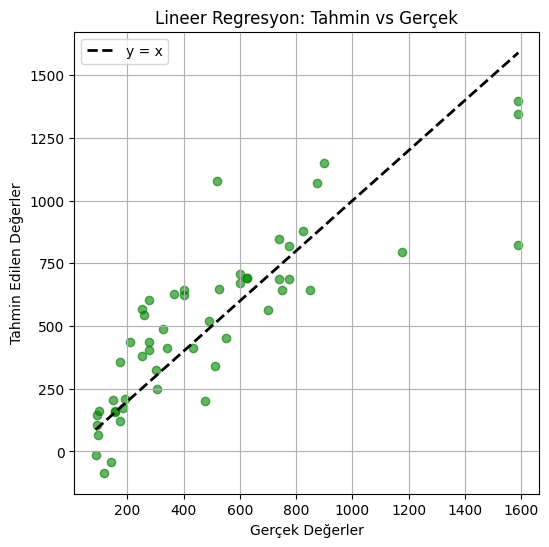

In [279]:


plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='y = x')
plt.xlabel("Gerçek Değerler")
plt.ylabel("Tahmin Edilen Değerler")
plt.title("Lineer Regresyon: Tahmin vs Gerçek")
plt.legend()
plt.grid(True)
plt.show()


**öncelikle sabit kendi belirlediğimiz bir alpha değerinden ridge ve lasso modeli oluşturuyoruz ki alphayı otomatik aldığımızda değişen farkları görebilelim.**

In [280]:

# Sabit Alfa Değeri
alpha = 20

# Ridge modelini oluştur
ridge = Ridge(alpha=alpha)

# Modeli eğit
ridge.fit(X_train_scaled, y_train)

# Test setinde tahmin yapma
y_pred_ridge = ridge.predict(X_test_scaled)

# Performans değerlendirmesi
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# Sonuçları yazdır
print(f"Ridge Modeli (Alpha: {alpha}):")
print(f"Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"R^2 Skoru: {r2_ridge:.2f}")

# Ridge Katsayılarını yazdır
print("Ridge Katsayıları:", ridge.coef_)


Ridge Modeli (Alpha: 20):
Mean Squared Error (MSE): 69974.90
R^2 Skoru: 0.50
Ridge Katsayıları: [-17.2653488   26.49832454  -0.15791306   8.74502092 -10.25915902
  -3.40981642 -57.23337334  19.93255728  60.02293755  77.26770374
  67.38624309  62.16677953  55.70861693  33.1901658   -0.52843298
   0.82279116 -30.9499915  -39.91594448 -24.11660776  43.06024979
 -11.11118622 -33.1927043  -87.76081997 -56.0982235   11.39752195
  81.9014681   13.51290803  55.41922567  -3.86884218  23.17519097
  11.88576712  -1.92274123  -1.24696923 -24.571743    -4.66160792
  22.75568417 -28.64672616  -4.98548043]


In [281]:
# Sabit Alfa Değeri
alpha = 20

# Lasso modelini oluştur
lasso = Lasso(alpha=alpha, max_iter=10000)

# Modeli eğit
lasso.fit(X_train_scaled, y_train)

# Test setinde tahmin yapma
y_pred_lasso = lasso.predict(X_test_scaled)

# Performans değerlendirmesi
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

# Sonuçları yazdır
print(f"Lasso Modeli (Alpha: {alpha}):")
print(f"Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"R^2 Skoru: {r2_lasso:.2f}")

# Lasso Katsayılarını yazdır
print("Lasso Katsayıları:", lasso.coef_)

Lasso Modeli (Alpha: 20):
Mean Squared Error (MSE): 76826.10
R^2 Skoru: 0.45
Lasso Katsayıları: [   0.           23.06373477    0.            0.            0.
    0.           -0.            0.            0.           48.9053692
    0.            0.           28.32078817   37.38045609    0.
    0.           -0.         -106.01949069   -0.           25.52932284
    0.            0.           -0.           -0.           35.44510461
   74.7948925     0.           54.84441625    0.            0.
    0.           -0.           -0.           -0.           -0.
    0.          -20.99189086    0.        ]


**Şimdi ridge ve lassoyu ridge_grid ve lasso_grip e atayacağımız çapraz doğrulama ile otomatik en iyi alpha değerini bulan kodla birlikte bulalım. en iyi sonucu bu verecek.**

In [282]:
# Ridge regresyon modeli
ridge_params = {'alpha': np.logspace(-3, 3, 50)}  # Alpha değerleri için geniş bir aralık
ridge = Ridge()
ridge_grid = GridSearchCV(ridge, ridge_params, scoring='r2', cv=5)  # Çapraz doğrulama ile en iyi alpha değerini bulma
ridge_grid.fit(X_train_scaled, y_train)

# En iyi Ridge modeli
best_ridge = ridge_grid.best_estimator_

# Ridge katsayılarını alma
ridge_coefficients = best_ridge.coef_

# Test setinde tahmin yapma
y_pred_ridge = best_ridge.predict(X_test_scaled)

# Performans değerlendirmesi
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
ridge_best_alpha = ridge_grid.best_params_['alpha']

# Sonuçları yazdır
print(f"Ridge Modeli (En iyi Alpha: {ridge_best_alpha}):")
print(f"Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"R^2 Skoru: {r2_ridge:.2f}")
print("Ridge Katsayıları:", ridge_coefficients)


Ridge Modeli (En iyi Alpha: 3.5564803062231287):
Mean Squared Error (MSE): 55362.97
R^2 Skoru: 0.61
Ridge Katsayıları: [ -93.18718145   65.10353493  -11.04646268    3.96494421  -59.43519999
  -36.1234994  -132.97214596   43.77525913  182.26068562  150.90360488
  143.25407273  102.63574038   69.99136064   17.45939641   -7.78248483
    8.05067956  -17.80308375  -52.7091822     2.27831883   61.84091224
  -39.73575616  -99.83799844 -175.30462446 -129.44264064   -1.43301236
  145.56528224   28.97231288   61.54520605  -16.5287151    37.92470444
   27.0705257     1.35603097    7.18071066  -18.21547785   -5.46045985
   35.7097521   -20.2423218   -14.23735722]


lasso_grid = GridSearchCV(lasso, lasso_params, scoring='r2', cv=5)  ile en iyi alpha değerini bulyoruz

In [283]:
# Lasso regresyon modeli
lasso_params = {'alpha': np.logspace(-3, 0, 50)}  # Lasso için daha küçük bir alpha aralığı
lasso = Lasso(max_iter=10000)
lasso_grid = GridSearchCV(lasso, lasso_params, scoring='r2', cv=5)
lasso_grid.fit(X_train_scaled, y_train)

# En iyi Lasso modeli
best_lasso = lasso_grid.best_estimator_

# Lasso katsayılarını alma
lasso_coefficients = best_lasso.coef_

# Test setinde tahmin yapma
y_pred_lasso = best_lasso.predict(X_test_scaled)

# Performans değerlendirmesi
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
lasso_best_alpha = lasso_grid.best_params_['alpha']

# Sonuçları yazdır
print(f"Lasso Modeli (En iyi Alpha: {lasso_best_alpha}):")
print(f"Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"R^2 Skoru: {r2_lasso:.2f}")
print("Lasso Katsayıları:", lasso_coefficients)

Lasso Modeli (En iyi Alpha: 1.0):
Mean Squared Error (MSE): 51218.84
R^2 Skoru: 0.63
Lasso Katsayıları: [-115.77359031   13.25278727   -0.           15.05728303  -51.4888966
  -30.66515177 -152.59429221   -0.          652.3338981    93.80599497
   48.54975891    0.           62.13884144    5.87034768   -7.16790624
    6.50377404   -0.          -46.02422884   -0.           78.11942512
  -47.25075608 -117.27233503 -414.10556503   -0.            0.
  164.66438184   31.76075305   52.45136518   -9.89476391   37.51023363
   75.15827774   -2.11199577    0.          -31.9136985   -13.37127905
   34.74675817  -16.31113909  -12.87461623]


alpha değerinin ridge ve lasso mse sine etkisini görselleştirerek bakıyoruz


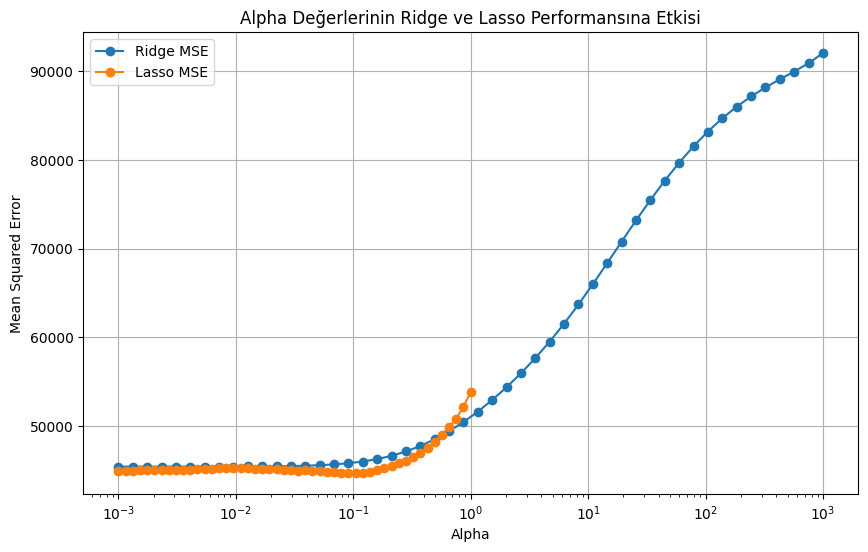

In [294]:
# Alpha değerlerini tanımla
ridge_params = {'alpha': np.logspace(-3, 3, 50)}
lasso_params = {'alpha': np.logspace(-3, 0, 50)}

ridge_mse = []
lasso_mse = []

# Ridge için alpha değerlerine göre MSE hesapla
for alpha in ridge_params['alpha']:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_scaled, y_train)
    ridge_pred = ridge_model.predict(X_test)
    ridge_mse.append(mean_squared_error(y_test, ridge_pred))

# Lasso için alpha değerlerine göre MSE hesapla
for alpha in lasso_params['alpha']:
    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    lasso_model.fit(X_train_scaled, y_train)
    lasso_pred = lasso_model.predict(X_test)
    lasso_mse.append(mean_squared_error(y_test, lasso_pred))

# Grafiği çiz
plt.figure(figsize=(10, 6))
plt.plot(ridge_params['alpha'], ridge_mse, label='Ridge MSE', marker='o')
plt.plot(lasso_params['alpha'], lasso_mse, label='Lasso MSE', marker='o')
plt.xscale('log')
plt.yscale('linear')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('Alpha Değerlerinin Ridge ve Lasso Performansına Etkisi')
plt.legend()
plt.grid(True)
plt.show()


bu grafiğe göre alpha değerleri lasso için en düşük mse olan 10^-1 ile 1 arasında gözüküyor, ridge için ise en düşük mse olan 10^-3 gözüküyor.

GridSearchCV’nin neden farklı alpha değerleri seçtiğini anlamlandırabilmek için bir araştırma yaptım ve şu sonuca ulaştım:

GridSearchCV, eğitim verisini birkaç parçaya böler ve her bir parça için çapraz doğrulama (cross-validation) uygular. Her alpha değeri için bu işlemi tekrarlar ve her seferinde doğrulama (validation) hatasını hesaplar. Sonuç olarak her alpha için ortalama MSE (Mean Squared Error) değeri elde eder. GridSearchCV, bu ortalama hatalara bakarak en düşük değeri veren alpha'yı seçer. Bu sayede daha genellenebilir, farklı veri kümelerinde de iyi performans gösterecek bir model parametresi belirlenmiş olur.

Öte yandan, bizim oluşturduğumuz MSE grafiğinde ise süreç daha farklı işler:

* Model her bir alpha değeri için eğitim seti üzerinde eğitilir.
* Daha sonra, yalnızca bir adet test seti üzerinde tahmin yapılır.
* Ve her alpha için tek bir test MSE değeri hesaplanır.

Bu nedenle, grafikte en düşük MSE’yi veren alpha değeri her zaman GridSearchCV tarafından seçilen alpha ile aynı olmayabilir. Çünkü grafik sadece belirli bir test setine dayanırken, GridSearchCV daha kapsamlı ve dengeli bir değerlendirme yapar.

**Örnek olarak:**

bizim grafiğimiz şöyle:

“Ben bu ayakkabıyı denedim, bana çok rahat geldi!”

GridSearchCV şöyle diyor:

“Ben bu ayakkabıyı 5 kişiyle test ettim. Biri çok beğendi ama diğerleri rahatsız buldu. O yüzden başka bir model öneriyorum.”

Şimdi sıra polinomal özellikler ekleyerek modelleri oluşturmada.
y = at^2+bt+c gibi bir ilişki varsa lineer model yetersiz kalır ve polinom özellikleri eklemek zorunda kalırız.  Polinom özelliklerini datanın kopyasını alarak oluşturdum



In [285]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y, test_size=0.2, random_state=42)

In [286]:
# Polinomsal özellikler ekleyerek modeli zenginleştirme
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_c)
X_test_poly = poly.transform(X_test_c)

In [287]:
#polinomsal özellikleri standardize etme
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

polinomal olarak lineer regresyon yapınca. r2 negatif çıktı. yani bu modeli açıklamakta hiç başarılı değil. bunun sebebi fazla features olması, multikoliner olması olabilir. Ya da polinomalin derecesi yüksek olduğundan overfittinge neden oluyor olabilir

In [288]:
# Lineer Regresyon Performans Değerlendirmesi
lr = LinearRegression()
lr.fit(X_train_poly_scaled, y_train_c)
y_pred_lr = lr.predict(X_test_poly_scaled)
mse_lr = mean_squared_error(y_test_c, y_pred_lr)
r2_lr = r2_score(y_test_c, y_pred_lr)

# Sonuçları yazdır
print(f"Lineer Regresyon (Polinom Eklendi):")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"R^2 Skoru: {r2_lr:.2f}")

Lineer Regresyon (Polinom Eklendi):
Mean Squared Error (MSE): 193067.78
R^2 Skoru: -0.38


ridge regresyonun da polinomal şeklindeki r2 değerleri düştü. bunun sebebi muhtemelen modelin karmaşıklığının artması oldu. Yani polinom özellikler orijinalleriyle yüksek korelasyon içeriyor olabilir. aynı şey lasso için de geçerli.

In [289]:
# Ridge regresyon modeli
ridge_params = {'alpha': np.logspace(-3, 3, 50)}  # Alpha değerleri için geniş bir aralık
ridge = Ridge()
ridge_grid = GridSearchCV(ridge, ridge_params, scoring='r2', cv=5)  # Çapraz doğrulama ile en iyi alpha değerini bulma
ridge_grid.fit(X_train_poly_scaled, y_train_c)

# En iyi Ridge modeli
best_ridge = ridge_grid.best_estimator_

# Ridge katsayılarını alma
ridge_coefficients = best_ridge.coef_

# Test setinde tahmin yapma
y_pred_ridge_c = best_ridge.predict(X_test_poly_scaled)

# Performans değerlendirmesi
mse_ridge_c = mean_squared_error(y_test_c, y_pred_ridge_c)
r2_ridge_c = r2_score(y_test_c, y_pred_ridge_c)
ridge_best_alpha_c = ridge_grid.best_params_['alpha']

# Sonuçları yazdır
print(f"Ridge Modeli (En iyi Alpha: {ridge_best_alpha_c}):")
print(f"Mean Squared Error (MSE): {mse_ridge_c:.2f}")
print(f"R^2 Skoru: {r2_ridge_c:.2f}")


Ridge Modeli (En iyi Alpha: 244.205309454865):
Mean Squared Error (MSE): 63102.65
R^2 Skoru: 0.55


In [290]:
# Lasso regresyon modeli
lasso_params = {'alpha': np.logspace(-3, 0, 50)}  # Lasso için daha küçük bir alpha aralığı
lasso = Lasso(max_iter=10000)
lasso_grid = GridSearchCV(lasso, lasso_params, scoring='r2', cv=5)
lasso_grid.fit(X_train_poly_scaled, y_train_c)

# En iyi Lasso modeli
best_lasso = lasso_grid.best_estimator_

# Lasso katsayılarını alma
lasso_coefficients = best_lasso.coef_

# Test setinde tahmin yapma
y_pred_lasso_c = best_lasso.predict(X_test_poly_scaled)

# Performans değerlendirmesi
mse_lasso_c = mean_squared_error(y_test_c, y_pred_lasso_c)
r2_lasso_c = r2_score(y_test_c, y_pred_lasso_c)
lasso_best_alpha_c = lasso_grid.best_params_['alpha']

# Sonuçları yazdır
print(f"Lasso Modeli (En iyi Alpha: {lasso_best_alpha_c}):")
print(f"Mean Squared Error (MSE): {mse_lasso_c:.2f}")
print(f"R^2 Skoru: {r2_lasso_c:.2f}")



Lasso Modeli (En iyi Alpha: 1.0):
Mean Squared Error (MSE): 81785.97
R^2 Skoru: 0.42


ridge ve lasso katsayıları çok yer kapladığı için ayrı almak istedim ve sonucu gizledim.

In [291]:
print("Ridge Katsayıları:", ridge_coefficients)
print("Lasso Katsayıları:", lasso_coefficients)

Ridge Katsayıları: [ 1.45726271e+01  1.57764822e+01  1.18721810e+01  1.62557079e+01
  1.15639067e+01  1.51814969e+01  9.90862492e+00  1.51621564e+01
  1.63405958e+01  1.49976746e+01  1.70827779e+01  1.57061378e+01
  1.71138743e+01  5.53654781e+00  2.18334348e+00  8.38396851e-01
 -1.29515144e+01 -1.48034057e+01 -1.24465685e+01  9.30391257e+00
  1.21705767e+01  9.05817979e+00  8.04787841e+00  8.72530386e+00
  2.13533365e+01  1.47654464e+01 -2.32246486e+00  2.39673831e+01
  5.40416589e+00 -2.98561491e+00 -3.74355789e+00  3.80784623e+00
 -2.51393693e+00 -5.10997055e+00  1.74823281e+00  2.63142874e+00
 -8.58378852e+00  4.05529815e+00 -7.59359056e-01 -1.06055333e+00
  2.21487662e+00 -7.08347772e-01 -4.91202998e-02 -2.43639301e-01
  3.31746239e+00  1.69772434e+00  1.36917064e+00  1.23527793e+00
  1.64989534e+00  5.67847680e-01  8.02602416e-01 -3.96980259e+00
 -6.24858104e+00 -2.37402709e+00 -5.45029585e+00 -4.81520323e+00
 -4.91677889e+00  3.79335445e+00 -2.84011810e-01 -1.09536570e+00
  8.70

pipeline kullanarak ridge ve lassoyu tekrar yapalım(alpha değeri otomatik bulunuyor ve polinomal yapıyor).

pipeline cross-validationdaki veri sızıntısını engeller ve daha hızlıdır

In [292]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Veriyi yükle
file_path = '/content/drive/MyDrive/RIDGE-LASSO/hitters_processed.pkl'
data_pipe = pd.read_pickle(file_path)

# X ve y'yi ayır
X_pipe = data_pipe.drop(columns=['Salary'])  # Hedef değişken: 'Salary'
y_pipe = data_pipe['Salary']  # Hedef değişken: 'Salary'

# Veriyi eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X_pipe, y_pipe, test_size=0.2, random_state=42)

# Polinomal özellikler oluştur
poly = PolynomialFeatures(degree=2, include_bias=False)

# Alpha değerlerini belirle
alpha_values = {'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0], 'lasso__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

# Ridge ve Lasso için pipeline oluştur
ridge_pipeline = Pipeline([
    ('poly', poly),
    ('ridge', Ridge())
])

lasso_pipeline = Pipeline([
    ('poly', poly),
    ('lasso', Lasso(max_iter=10000))
])

# Ridge için GridSearchCV uygulama
ridge_search = GridSearchCV(ridge_pipeline, param_grid={'ridge__alpha': alpha_values['ridge__alpha']}, cv=5, scoring='neg_mean_squared_error')
ridge_search.fit(X_train, y_train)

# Lasso için GridSearchCV uygulama
lasso_search = GridSearchCV(lasso_pipeline, param_grid={'lasso__alpha': alpha_values['lasso__alpha']}, cv=5, scoring='neg_mean_squared_error')
lasso_search.fit(X_train, y_train)

# En iyi alpha değerlerini al
best_ridge_alpha = ridge_search.best_params_['ridge__alpha']
best_lasso_alpha = lasso_search.best_params_['lasso__alpha']

# En iyi modelleri yeniden eğit
ridge_best_model = ridge_search.best_estimator_
lasso_best_model = lasso_search.best_estimator_

# Tahminler yap
ridge_best_preds = ridge_best_model.predict(X_test)
lasso_best_preds = lasso_best_model.predict(X_test)

# Modelleri değerlendir
results = pd.DataFrame({
    "Model": ["Optimized Ridge Regression", "Optimized Lasso Regression"],
    "Best Alpha": [best_ridge_alpha, best_lasso_alpha],
    "MSE": [
        mean_squared_error(y_test, ridge_best_preds),
        mean_squared_error(y_test, lasso_best_preds)
    ],
    "R2 Score": [
        r2_score(y_test, ridge_best_preds),
        r2_score(y_test, lasso_best_preds)
    ]
})

print(results)


                        Model  Best Alpha           MSE  R2 Score
0  Optimized Ridge Regression       100.0  65734.922802  0.531393
1  Optimized Lasso Regression        10.0  64507.414295  0.540144


***özet:***

**burada farklı regresyon modelleri ile veri seti üzerinde tahmin performanslarını inceledik. Lineer, Ridge ve Lasso regresyonu hem normal hemde polinomsal olarak kullandık. Polinomsal regresyon yüksek hata oranı nedeniyle zayıf performans sergilerken, Ridge ve Lasso modelleri daha düşük R2 değerleri verdi. Ayrıca, Pipeline ve GridSearchCV kullanıp daha güvenli hale getirdik.**